In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm


In [3]:
df = pd.read_csv("../data/20220705_q16f_12-pt_mm.csv", header=0)

In [7]:
df.replace("OVER", np.nan, inplace=True)

In [8]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],H1,H2,H3,H4,H5,H6,H7,...,I15,I16,I17,I18,I19,I20,I21,I22,I23,I24
0,1,0.000,27.2,50638,48334,35283,21528,15169,10725,5589,...,409,431,290,413,234,288,289,220,260,201
1,2,31.443,27.2,56664,54697,37618,24480,17747,12088,6011,...,401,431,290,409,240,287,285,239,261,206
2,3,62.396,27.2,61637,60265,42639,28272,20112,14080,6640,...,410,438,292,422,230,289,282,230,256,198
3,4,93.350,27.2,66042,65174,46390,32150,22677,15878,7319,...,399,426,287,418,241,295,283,222,262,201
4,5,124.305,27.2,NaN,NaN,50519,35816,25091,17791,8204,...,398,430,289,423,240,284,282,228,267,202


In [9]:
times = np.tile(df["Time [s]"], (24,1))

In [10]:
times

array([[   0.   ,   31.443,   62.396, ..., 7213.231, 7244.196, 7275.147],
       [   0.   ,   31.443,   62.396, ..., 7213.231, 7244.196, 7275.147],
       [   0.   ,   31.443,   62.396, ..., 7213.231, 7244.196, 7275.147],
       ...,
       [   0.   ,   31.443,   62.396, ..., 7213.231, 7244.196, 7275.147],
       [   0.   ,   31.443,   62.396, ..., 7213.231, 7244.196, 7275.147],
       [   0.   ,   31.443,   62.396, ..., 7213.231, 7244.196, 7275.147]])

In [11]:
time_arr = times[0]

## MM Functions

In [12]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [110]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    
    min_inclusion = max(len(perc_times) * min_included_percent // 100, 5)
    
    for i in range(len(perc_times), min_inclusion, -1):
        curr_times = [item for sublist in perc_times[:i] for item in sublist]
        curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    
    if len(scores) == 0 and min_included_percent == 100:
        reg = LinearRegression().fit(np.array(perc_times).reshape(-1,1), perc_concs)
        curr_score = reg.score(np.array(perc_times).reshape(-1,1), perc_concs)
        return reg.coef_.item(), reg.intercept_.item(), curr_score
    
    max_r2_idx = np.argmax(scores)
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]

In [14]:
sub_concs = [16000, 8000, 4000, 2000, 1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

In [94]:
def get_all_initial_slopes(time_arr: np.array, kinetic_data: np.array, substrate_concs: [int], title: str, fig_size: (int, int) = (10,10), min_included_percent: int = 5):
    
    rep_1_arr = kinetic_data[0::2]
    rep_2_arr = kinetic_data[1::2]
    
    rep_1_slopes = []
    rep_2_slopes = []

    fig = plt.figure(figsize=fig_size) 
    for data, sub_conc in zip(rep_1_arr, sub_concs):
        if np.any(np.isnan(data)):
            # print(sub_conc)
            # print(np.sum(np.isnan(data)))
            # print(((100-min_included_percent) / 100) * len(data))
            if np.sum(np.isnan(data)) > ((100-min_included_percent) / 100) * len(data):
                slope, intercept, score = compute_initial_reaction_slope(time_arr[~np.isnan(data)], data[~np.isnan(data)], 100)
            else:
                slope, intercept, score = compute_initial_reaction_slope(time_arr[~np.isnan(data)], data[~np.isnan(data)], min_included_percent)
            
        else:
            slope, intercept, score = compute_initial_reaction_slope(time_arr, data, min_included_percent)
        rep_1_slopes.append(slope)
        plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
        #print(x, slope, intercept,score)
        plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    plt.title(f"{title} Replicate 1")
    plt.xlabel("Time (seconds)")
    plt.ylabel("µM")
    plt.legend() 
    
    fig = plt.figure(figsize=fig_size) 
    for data, sub_conc in zip(rep_2_arr, sub_concs):
        if np.any(np.isnan(data)):
            if np.sum(np.isnan(data)) > ((100-min_included_percent) / 100) * len(data):
                slope, intercept, score = compute_initial_reaction_slope(time_arr[~np.isnan(data)], data[~np.isnan(data)], 100)
            else:
                slope, intercept, score = compute_initial_reaction_slope(time_arr[~np.isnan(data)], data[~np.isnan(data)], min_included_percent)
        else:
            slope, intercept, score = compute_initial_reaction_slope(time_arr, data, min_included_percent)
        plt.scatter(time_arr, data)
        rep_2_slopes.append(slope)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
        plt.plot(x, x*slope + intercept, linewidth=3, label=f"{sub_conc:.2f} µM")
    plt.title(f"{title} Replicate 2")
    plt.xlabel("Time (seconds)")
    plt.ylabel("µM")
    plt.legend() 
    plt.show()
    return rep_1_slopes, rep_2_slopes

In [16]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [139]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [int], e_conc: float, title: str, background_rates: np.array = None):
    avg_slopes = np.mean([rep_1_slopes, rep_2_slopes], axis=0)
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.std([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, sub_concs[0], 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} µM")

# Q16f

In [19]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],H1,H2,H3,H4,H5,H6,H7,...,I15,I16,I17,I18,I19,I20,I21,I22,I23,I24
0,1,0.000,27.2,50638,48334,35283,21528,15169,10725,5589,...,409,431,290,413,234,288,289,220,260,201
1,2,31.443,27.2,56664,54697,37618,24480,17747,12088,6011,...,401,431,290,409,240,287,285,239,261,206
2,3,62.396,27.2,61637,60265,42639,28272,20112,14080,6640,...,410,438,292,422,230,289,282,230,256,198
3,4,93.350,27.2,66042,65174,46390,32150,22677,15878,7319,...,399,426,287,418,241,295,283,222,262,201
4,5,124.305,27.2,NaN,NaN,50519,35816,25091,17791,8204,...,398,430,289,423,240,284,282,228,267,202


In [53]:
gs_q16f_df = df.iloc[:, 3:27]
gs_q16f_arr = np.array(gs_q16f_df).T.astype(float)

In [54]:
gs_q16f_arr

array([[50638., 56664., 61637., ...,    nan,    nan,    nan],
       [48334., 54697., 60265., ...,    nan,    nan,    nan],
       [35283., 37618., 42639., ...,    nan,    nan,    nan],
       ...,
       [  372.,   369.,   385., ...,   383.,   381.,   386.],
       [  428.,   429.,   433., ...,   419.,   422.,   420.],
       [  367.,   350.,   353., ...,   347.,   351.,   344.]])

In [21]:
gs_q16f_df

,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,...,H15,H16,H17,H18,H19,H20,H21,H22,H23,H24
0,50638,48334,35283,21528,15169,10725,5589,6773,2749,2618,...,545,589,533,439,534,384,363,372,428,367
1,56664,54697,37618,24480,17747,12088,6011,7376,3014,2870,...,542,585,537,439,540,382,373,369,429,350
2,61637,60265,42639,28272,20112,14080,6640,8123,3309,3116,...,544,598,536,456,543,388,370,385,433,353
3,66042,65174,46390,32150,22677,15878,7319,8999,3693,3391,...,559,595,538,442,540,384,369,416,429,364
4,NaN,NaN,50519,35816,25091,17791,8204,9935,4002,3721,...,553,590,554,450,537,387,374,389,427,362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43654,45442,...,2648,2564,928,803,566,450,377,390,421,351
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44075,45920,...,2636,2589,928,822,562,459,388,387,419,348
233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44149,46060,...,2661,2617,940,817,567,459,384,383,419,347
234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44135,45774,...,2657,2613,941,810,572,454,385,381,422,351


In [22]:
gs_q16f_conc = .789 * (1/50)

# Computing Background Rates

In [23]:
q16f_no_enz_df = df.iloc[:, 27:51]
q16f_no_enz_arr = np.array(q16f_no_enz_df).T

In [59]:
np.sum(np.isnan(q16f_no_enz_arr)[0])

1

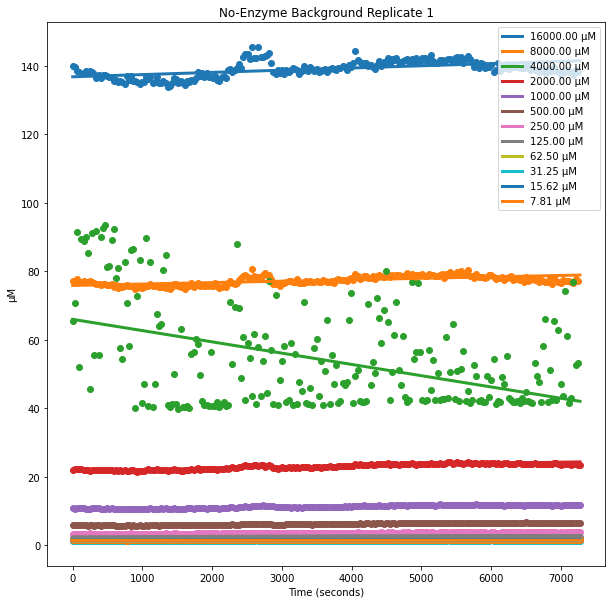

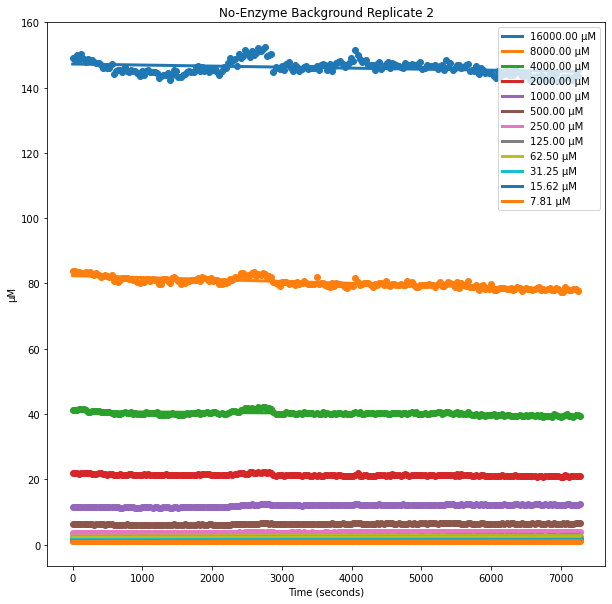

In [49]:
q16f_no_enz_r1_slopes, q16f_no_enz_r2_slopes = get_all_initial_slopes(time_arr, q16f_no_enz_arr / 179, sub_concs, "No-Enzyme Background", min_included_percent=75)

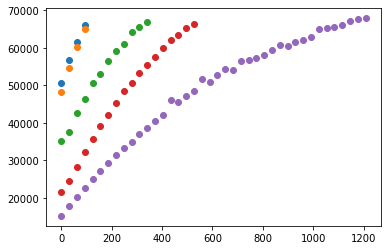

In [91]:
plt.scatter(time_arr, gs_q16f_arr[0])
plt.scatter(time_arr, gs_q16f_arr[1])
plt.scatter(time_arr, gs_q16f_arr[2])
plt.scatter(time_arr, gs_q16f_arr[3])
plt.scatter(time_arr, gs_q16f_arr[4])

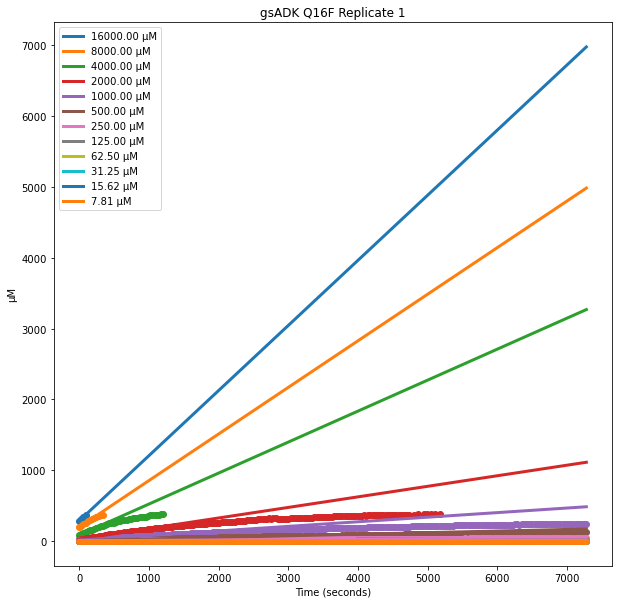

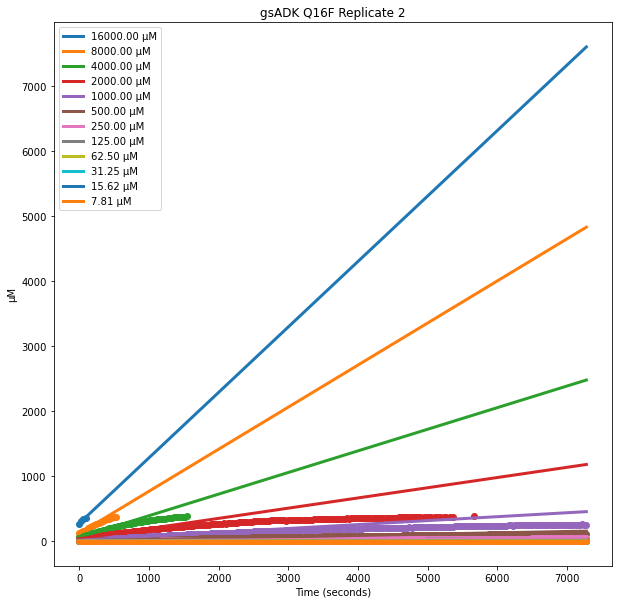

In [111]:
gsADK_q16f_r1_slopes, gsADK_q16f_r2_slopes = get_all_initial_slopes(time_arr, (gs_q16f_arr / 179), sub_concs, "gsADK Q16F")

In [104]:
q16f_no_enz_r1_slopes[2] = q16f_no_enz_r2_slopes[2]

In [131]:
gsADK_q16f_r1_slopes[0] = gsADK_q16f_r1_slopes[0][0]

In [136]:
gsADK_q16f_r2_slopes[0] = gsADK_q16f_r2_slopes[0][0]

In [137]:
gsADK_q16f_r2_slopes

[array([1.00771113]),
 array([0.64766495]),
 array([0.33276961]),
 array([0.15718906]),
 array([0.0605765]),
 array([0.0204686]),
 array([0.00599263]),
 array([0.00168552]),
 array([0.00031031]),
 array([5.40947183e-05]),
 array([0.00019169]),
 array([-5.09093624e-05])]

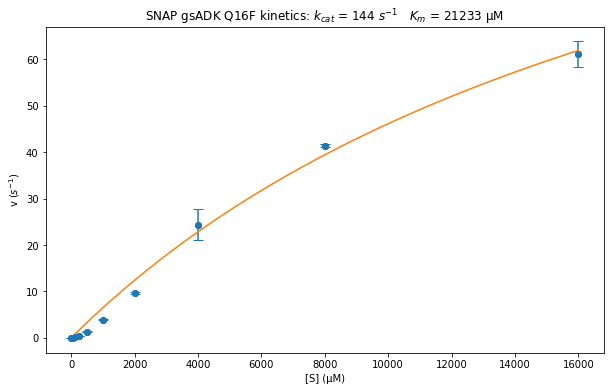

In [140]:
fit_and_plot_micheaelis_menten(gsADK_q16f_r1_slopes, gsADK_q16f_r2_slopes, sub_concs, 
                               gs_q16f_conc, "SNAP gsADK Q16F", np.mean([q16f_no_enz_r1_slopes, q16f_no_enz_r2_slopes], axis=0))


# R88G

In [30]:
r88g_df = pd.read_csv("../data/20220525_R88G_full_mm.csv", header=0)

In [52]:
gs_r88g_df = r88g_df.iloc[:, 3:18]
gs_r88g_df["N16"] = gs_r88g_df["N15"]

gs_r88g_arr = np.array(gs_r88g_df).T

In [40]:
r88g_no_enz_df = r88g_df.iloc[:, 18:33]
r88g_no_enz_df["O16"] = r88g_no_enz_df["O15"]
r88g_no_enz_arr = np.array(r88g_no_enz_df).T

In [51]:
r88g_no_enz_arr.shape

(16, 994)

In [45]:
r88g_times = np.tile(r88g_df["Time [s]"], (16,1))

In [46]:
r88g_time_arr = r88g_times[0]

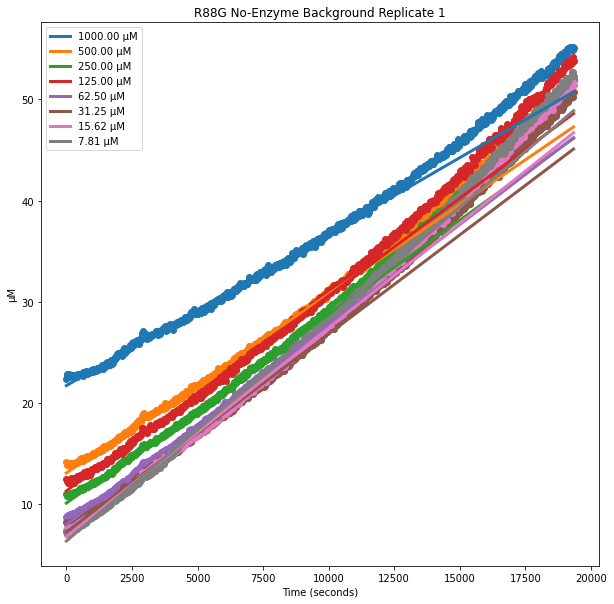

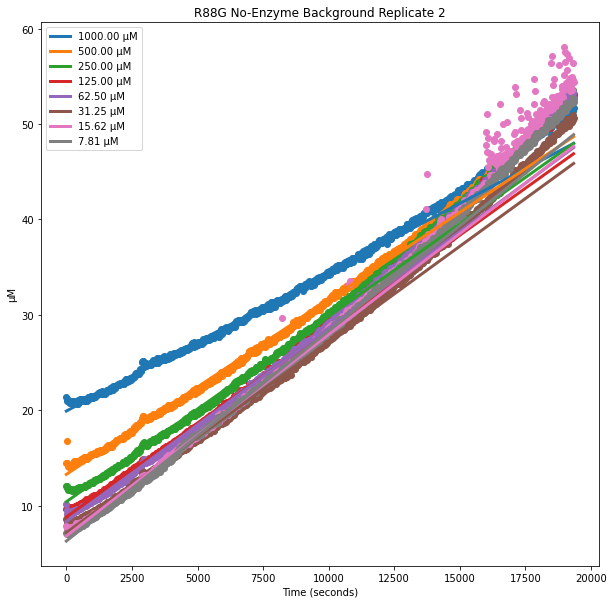

In [47]:
r88g_no_enz_r1_slopes, r88g_no_enz_r2_slopes = get_all_initial_slopes(r88g_time_arr, r88g_no_enz_arr / 179, sub_concs, "R88G No-Enzyme Background")

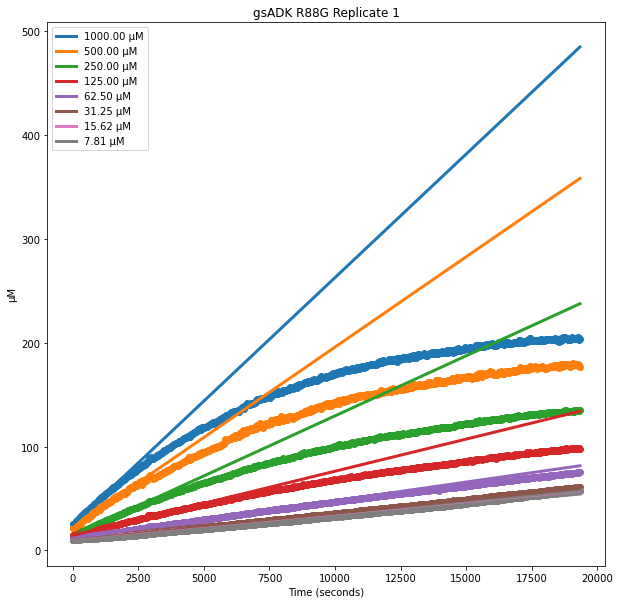

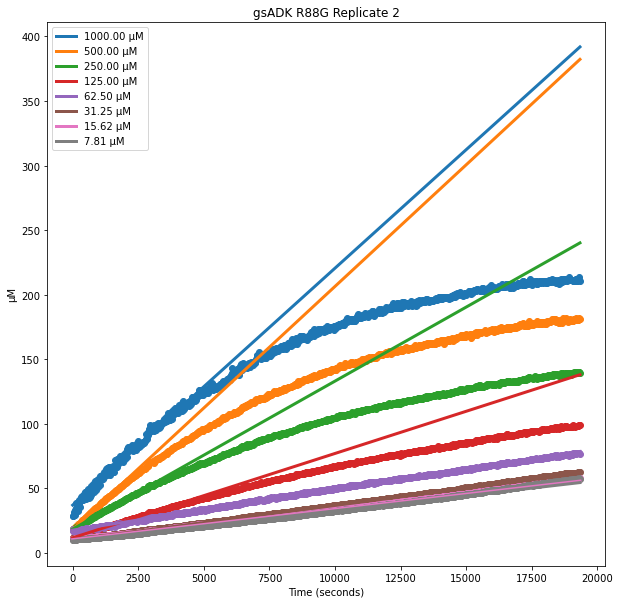

In [53]:
gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes = get_all_initial_slopes(r88g_time_arr, gs_r88g_arr / 179, sub_concs, "gsADK R88G")

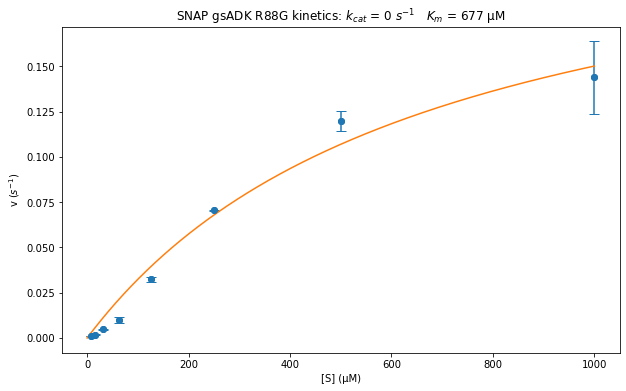

In [55]:
fit_and_plot_micheaelis_menten(gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes, sub_concs, .681 * (30/150), "SNAP gsADK R88G", np.mean([r88g_no_enz_r1_slopes, r88g_no_enz_r2_slopes], axis=0))

In [73]:
gs_r88g_df = df.iloc[:, 2:18]
gs_r88g_arr = np.array(gs_r88g_df).T

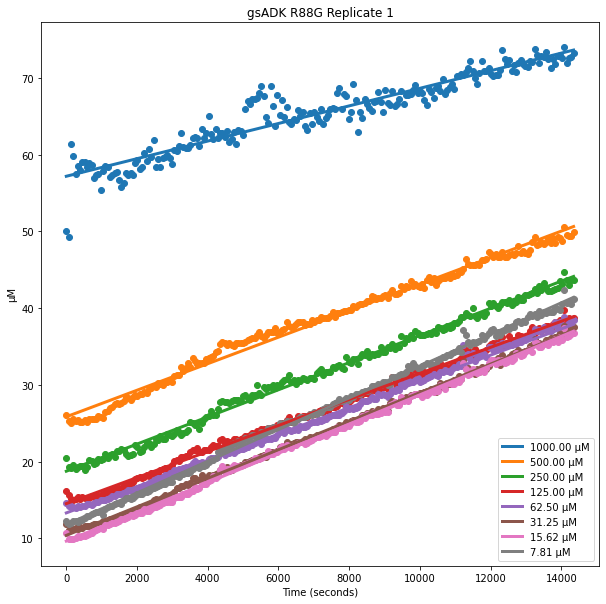

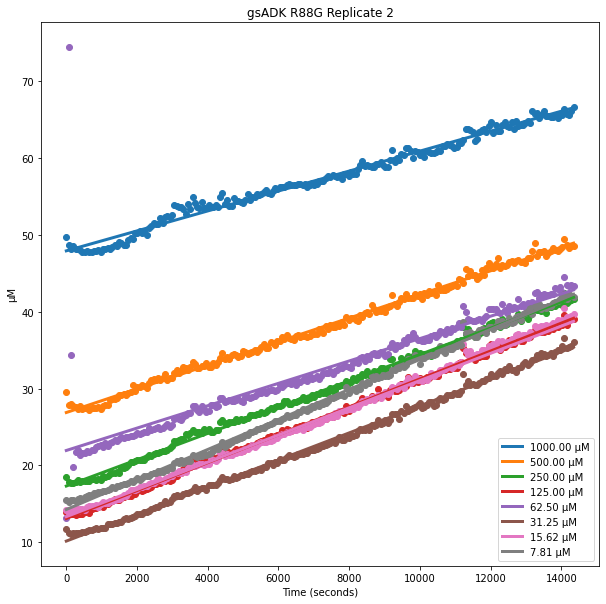

In [74]:
gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes = get_all_initial_slopes(time_arr, gs_r88g_arr / 179, sub_concs, "gsADK R88G")

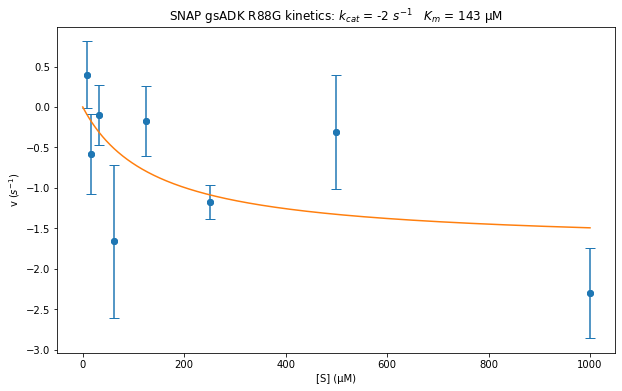

In [75]:
fit_and_plot_micheaelis_menten(gsADK_r88g_r1_slopes, gsADK_r88g_r2_slopes, sub_concs, .681 * 2e-4, "SNAP gsADK R88G", np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))

In [100]:
def multi_mm_plots(samples: [(np.array, np.array, float, str)], sub_concs: [int], title: str, cmap_bound: (int, int) = (0,1), background_rates: np.array = None,):
    plt.figure(figsize=(10,10))
    cmap = cm.get_cmap('plasma')

    color_vals = np.linspace(cmap_bound[0], cmap_bound[1], len(samples))
    print(len(samples))
    for sample, color_val in zip(samples, color_vals):
        rep_1_slopes, rep_2_slopes, e_conc, label = sample
        avg_slopes = np.mean([rep_1_slopes, rep_2_slopes], axis=0)
        if background_rates is not None:
            avg_slopes -= background_rates
        errs = np.std([rep_1_slopes, rep_2_slopes], axis=0) 
        params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))


        plt.scatter(sub_concs, avg_slopes/e_conc, color=cmap(color_val))
        plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5, color=cmap(color_val))
        x = np.linspace(0, 1000, 1000)
        k_cat = f"{params[0] / e_conc:.0f}"
        K_m = f"{params[1]:.0f}"
        prop_label = label + ": $k_{cat}$=" + k_cat + " $s^{-1}$ " + f"  $K_m$=" +  K_m + " µM"
        plt.plot(x, mm_model(x, params[0], params[1]) / e_conc, color=cmap(color_val), label=prop_label)
        plt.legend()
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title)

3


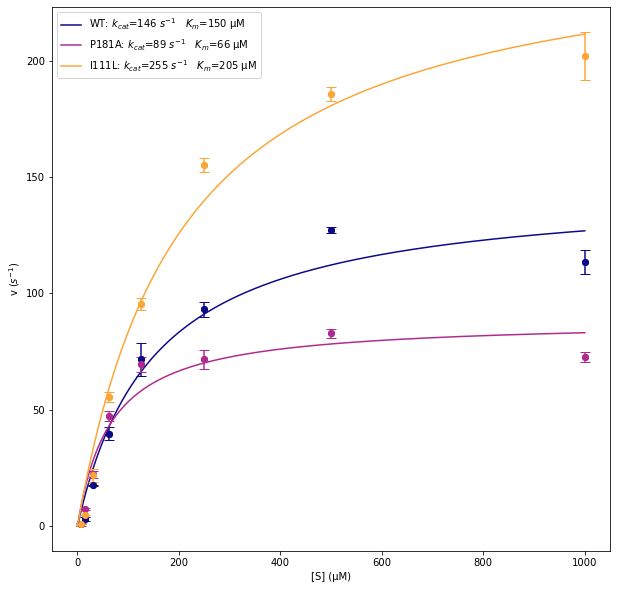

In [102]:
multi_mm_plots([(gsADK_wt_r1_slopes, gsADK_wt_r2_slopes, .652*2e-4,"WT"),
                (gsADK_p181a_r1_slopes, gsADK_p181a_r2_slopes, .885*2e-4, "P181A"),
                (gsADK_i111l_r1_slopes, gsADK_i111l_r2_slopes, .618*2e-4, "I111L")],
               sub_concs, "gsADK MM Kinetics", cmap_bound = (0,0.8), background_rates=np.mean([no_enz_r1_slopes, no_enz_r2_slopes], axis=0))